In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [70]:
data = load_iris()

In [71]:
df = pd.DataFrame()
df[data['feature_names']] = data['data']
df['label'] = data['target']

In [72]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [73]:
label_table = pd.DataFrame({
    'label': range(len(data.target_names)),
    'species': data.target_names
})
label_table

,label,species
0,0,setosa
1,1,versicolor
2,2,virginica


In [74]:
df.shape

(150, 5)

In [75]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   label              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [76]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


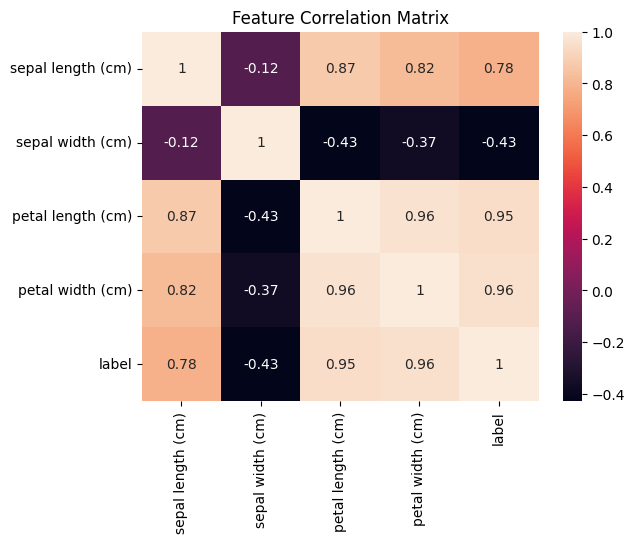

In [77]:
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

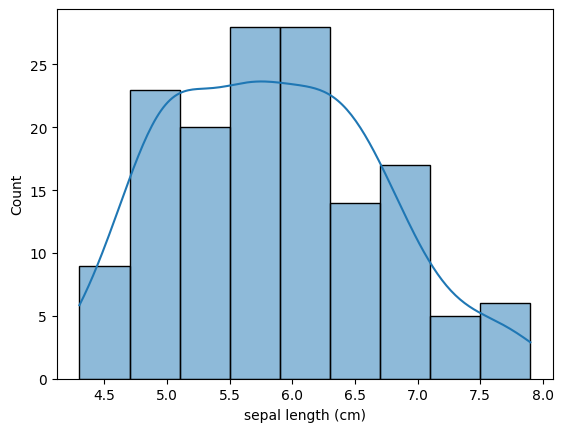

In [78]:
sns.histplot(df["sepal length (cm)"], kde=True)
plt.show()

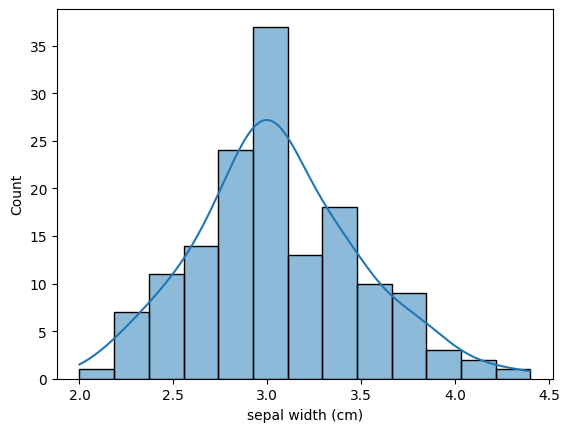

In [79]:
sns.histplot(df["sepal width (cm)"], kde=True)
plt.show()

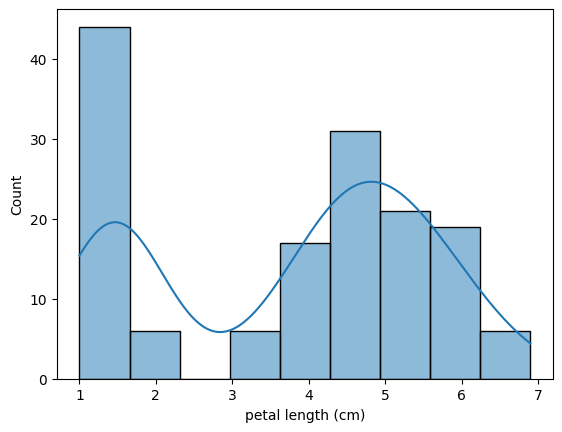

In [80]:
sns.histplot(df["petal length (cm)"], kde=True)
plt.show()

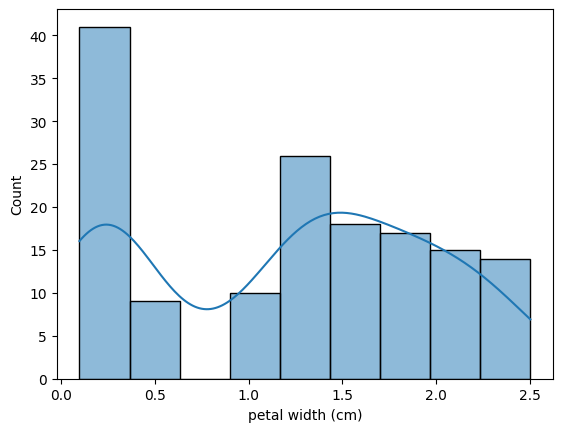

In [81]:
sns.histplot(df["petal width (cm)"], kde=True)
plt.show()

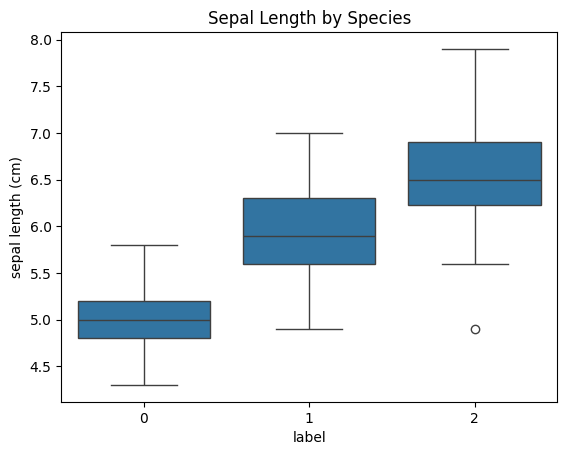

In [82]:
sns.boxplot(x=df['label'], y=df["sepal length (cm)"])
plt.title("Sepal Length by Species")
plt.show()

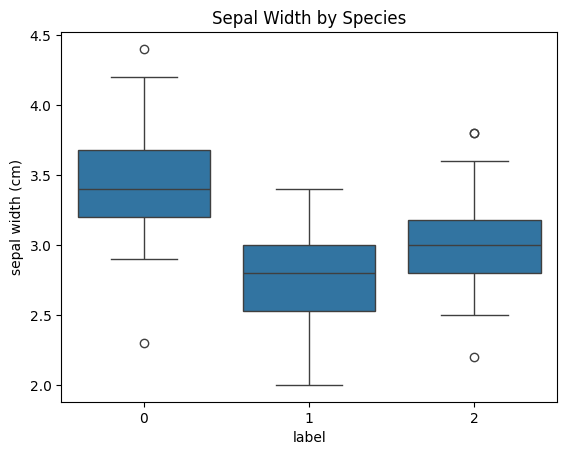

In [83]:
sns.boxplot(x=df['label'], y=df["sepal width (cm)"])
plt.title("Sepal Width by Species")
plt.show()

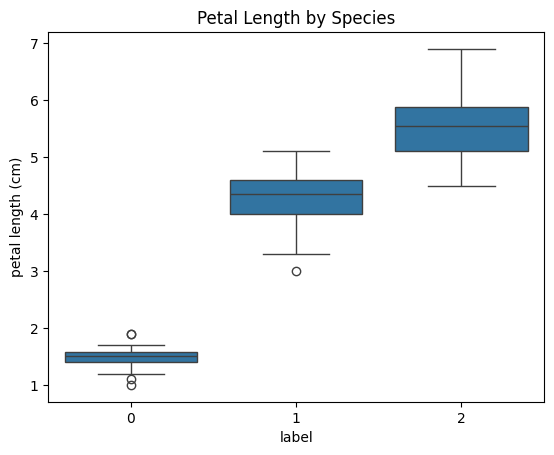

In [84]:
sns.boxplot(x=df['label'], y=df["petal length (cm)"])
plt.title("Petal Length by Species")
plt.show()

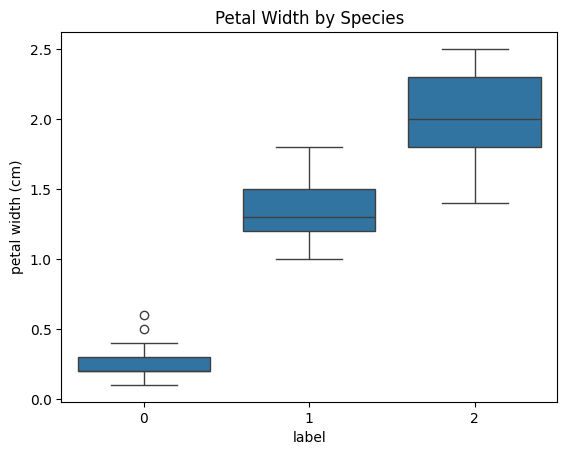

In [85]:
sns.boxplot(x=df['label'], y=df["petal width (cm)"])
plt.title("Petal Width by Species")
plt.show()

In [86]:
outliers = pd.DataFrame()

In [87]:
for col in data['feature_names']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers[col + '_outlier'] = (df[col] < lower_bound) | (df[col] > upper_bound)

In [88]:
df_outliers = df[outliers.any(axis=1)]
df_outliers

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
15,5.7,4.4,1.5,0.4,0
32,5.2,4.1,1.5,0.1,0
33,5.5,4.2,1.4,0.2,0
60,5.0,2.0,3.5,1.0,1
